In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov




/tmp/ipykernel_2215817/667692420.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
def get_samps(fname, acorr_max = 0.075, acorr_min = 0.0075):
    df = pk.load(open(fname,'rb'))
    sig8 = df['sigma8']
    nchains = 64
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    print(len(ind_del))
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys

# ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# samps, keys = get_samps(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Feb/'
probe = 'xip_xim'
# probe = 'all'
# samps, keys = get_samps(ldir + 'mcmc_v10_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
samps, keys = get_samps(ldir + f'mcmc_v10_widemuej_nzfix_probe_{probe}_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps, keys = get_samps(ldir + f'mcmc_v11_nzfix_probe_{probe}_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')

nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, 64))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 512))





6
(232000, 22) (58, 4000, 22)


In [3]:
indsel


array([   561,   1072,   1358,   3377,   3396,   4854,   8498,  19314,
        22147,  26623,  29457,  31010,  38954,  40443,  41785,  41991,
        42691,  43292,  43425,  49501,  55773,  70495,  71995,  74568,
        77338,  77847,  83470,  89484,  91436,  95047, 106254, 115485,
       124228, 129949, 134673, 140673, 141954, 142439, 146184, 150871,
       152682, 159948, 166452, 166679, 169355, 172501, 173071, 176952,
       179159, 179575, 186312, 189388, 196325, 196625, 199161, 201820,
       205449, 206608, 208352, 209223, 221543, 226299, 226437, 231686])

In [5]:
from tqdm import tqdm
from base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
from jax import jit, vmap
import interpax
import jax.scipy.integrate as jsi
# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

# Y_model_all_samp = []
Cl_yy_all_samp = []

# for map_ind in tqdm(indsel):
for map_ind in tqdm(indsel[0:10]):   
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']

    # halo_params_dict['rmax'] = 12.0
    # halo_params_dict['nr'] = 128
    # halo_params_dict['nk'] = 96
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    vmapped_func = get_vmapped_func_warg(Pkz_test.get_P_1h, 2, 4)
    Pyy_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test.nk), jnp.arange(Pkz_test.nz), 3, 3).T
    Pyy_2h_kz_mat = Pkz_test.by_kz_mat * Pkz_test.by_kz_mat * Pkz_test.plin_kz_mat
    Pyy_tot_mat = Pyy_1h_kz_mat + Pyy_2h_kz_mat
    # Bl_array = jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.)
    # Bl_mat = Bl_array[:, None]

    @jit
    def get_P_lz(jl, jz, Pk_mat):
        ell = base_test.ell_array[jl]
        chi_z = base_test.chi_array[jz]
        k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
        Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(base_test.kPk_array), jnp.log(Pk_mat[:,jz])))
        return Pkz_ell

    vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
    Pkyy_lz_mat = vmapped_func(jnp.arange(base_test.nell), jnp.arange(base_test.nz), Pyy_tot_mat).T

    # Pkyy_lz_mat = Pkyy_lz_mat * (Bl_mat**2)
    logPkyylz_2d_interp = interpax.Interpolator2D(jnp.log(base_test.ell_array), base_test.z_array, jnp.log(Pkyy_lz_mat), extrap=True)        

    @jit
    def get_Cl_tot(jl):
        Pk = jnp.exp(logPkyylz_2d_interp(jnp.log(base_test.ell_array[jl]), base_test.z_array_for_Cls))
        Wy_array = (1.0 / (1.0 + base_test.z_array_for_Cls))

        prefac = Wy_array / (base_test.chi_array_for_Cls**2)
        fx = prefac * prefac  * (base_test.chi_array_for_Cls ** 2) * base_test.dchi_dz_array_for_Cls * Pk
        return jsi.trapezoid(fx, x=base_test.z_array_for_Cls)     
    
    Cl_yy = vmap(get_Cl_tot)(jnp.arange(base_test.nell))
    Cl_yy_all_samp.append(Cl_yy)
    # ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    # Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))




100%|██████████| 10/10 [02:04<00:00, 12.47s/it]


In [ ]:
# Pyy_1h_kz_mat
sim_params_dict




{'cosmo': {'flat': True,
  'H0': 67.2,
  'Om0': 0.3472970286929607,
  'Ob0': 0.04586791062680537,
  'sigma8': 0.728964645920485,
  'ns': 1.0154370381000317,
  'w0': -1.0},
 'init_power': True,
 'nfw_trunc': True,
 'epsilon_rt': 4.0,
 'theta_ej_0': 2.656797402872292,
 'log10_Mstar0_theta_ej': 16.0,
 'nu_theta_ej_M': -0.11052717182003371,
 'nu_theta_ej_z': -0.5689633849033846,
 'theta_co_0': 0.05,
 'log10_Mstar0_theta_co': 16.0,
 'nu_theta_co_M': 0.0,
 'nu_theta_co_z': 0.0,
 'mu_beta': 1.2156306874349563,
 'log10_Mstar0': 14.0,
 'log10_Mc0': 13.75,
 'nu_z': 0.0,
 'nu_M': 0.0,
 'gamma_rhogas': 2.0,
 'delta_rhogas': 7.0,
 'a_zeta': 0.3,
 'n_zeta': 2.0,
 'alpha_nt': 0.25438893555977576,
 'beta_nt': 0.5,
 'n_nt': 0.3,
 'log10M1_fshmr': 12.35,
 'log10M1_a_fshmr': 0.28,
 'log10Mstar0_fshmr': 10.72,
 'log10Mstar0_a_fshmr': 0.55,
 'beta_fshmr': 0.44,
 'beta_a_fshmr': 0.18,
 'delta_fshmr': 0.57,
 'delta_a_fshmr': 0.17,
 'gamma_fshmr': 1.56,
 'gamma_a_fshmr': 2.51,
 'siglogMstar_Ncen': 0.25,
 'alp

In [64]:
Pyy_2h_kz_mat


Array([[4.52615860e-17, 5.41841824e-17, 6.05214212e-17, ...,
        1.51709780e-17, 1.32564681e-17, 1.15023296e-17],
       [6.15333625e-17, 7.36636790e-17, 8.22791883e-17, ...,
        2.06250238e-17, 1.80222376e-17, 1.56374772e-17],
       [8.36465169e-17, 1.00136087e-16, 1.11847740e-16, ...,
        2.80370084e-17, 2.44988628e-17, 2.12570945e-17],
       ...,
       [3.16462636e-28, 3.06176363e-28, 2.84568806e-28, ...,
        7.61019989e-30, 6.04276865e-30, 4.82886374e-30],
       [2.20651163e-29, 2.13522768e-29, 1.98940666e-29, ...,
        5.84373128e-31, 4.65650119e-31, 3.73332934e-31],
       [2.06328273e-30, 1.99783754e-30, 1.86542688e-30, ...,
        5.94562531e-32, 4.76075310e-32, 3.83615274e-32]], dtype=float64)

In [10]:
import matplotlib.pyplot as pl
%matplotlib inline




(100.0, 6000.0)

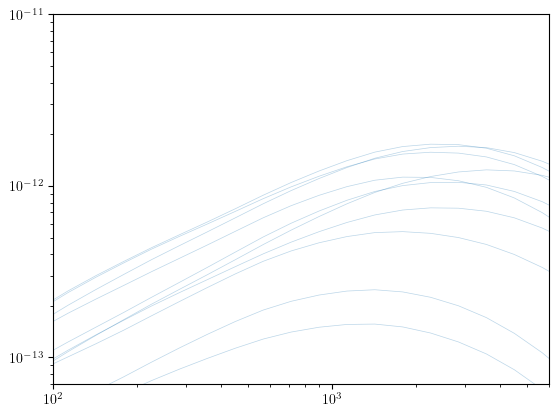

In [69]:
# Cl_yy
fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
# pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')
for Cl_yy in Cl_yy_all_samp:
    pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14, 1e-11)
pl.xlim(1e2, 6e3)




In [6]:
fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))[None,:]

Dl_yy_all_samp = fac * np.array(Cl_yy_all_samp)
# Pmm_ratio_all_samp_mean = np.mean(Pmm_ratio_all_samp, axis=0)
# Pmm_ratio_all_samp_std = np.std(Pmm_ratio_all_samp, axis=0)
Dlyymin = np.percentile(Dl_yy_all_samp, 16, axis=0)
Dlyymax = np.percentile(Dl_yy_all_samp, 84, axis=0)



In [7]:
# Dlyymin
Cl_yy_all_samp = np.array(Cl_yy_all_samp)


In [8]:
Cl_yy_all_samp.shape


(10, 37)

(100.0, 6000.0)

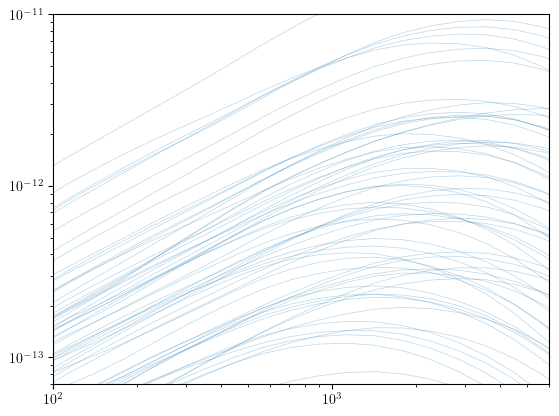

In [61]:
# Cl_yy
fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
# pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')
for Cl_yy in Cl_yy_all_samp:
    pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14, 1e-11)
pl.xlim(1e2, 6e3)




(100.0, 6000.0)

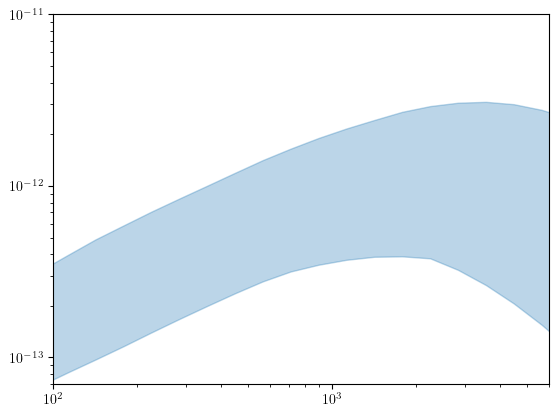

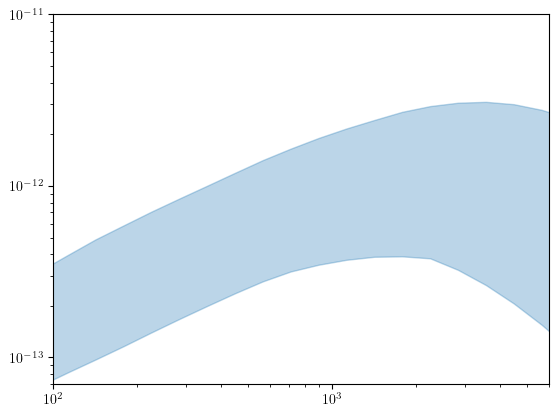

In [11]:
# Cl_yy
fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='shear-2pt only')
# for Cl_yy in Cl_yy_all_samp:
#     pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

pl.xscale('log')
pl.yscale('log')
pl.ylim(7e-14, 1e-11)
pl.xlim(1e2, 6e3)




In [12]:
import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)


In [14]:
fnameDl_yy_planck = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


In [17]:

act_Dl_ratio = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]


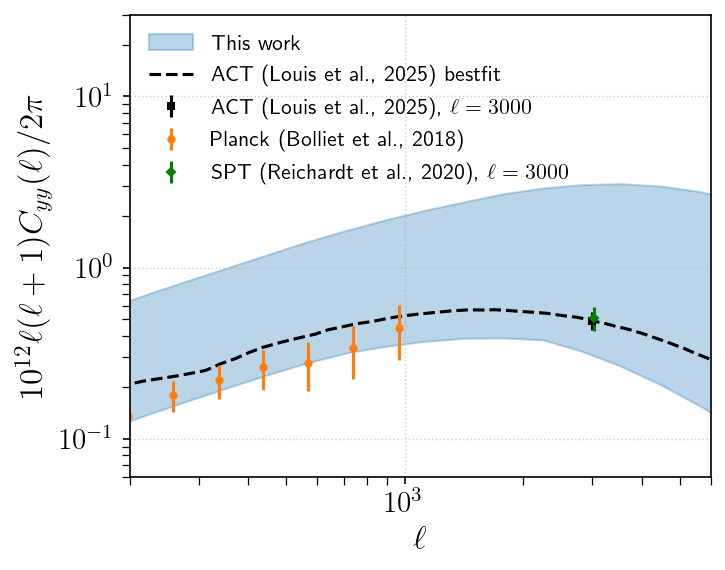

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
plt.fill_between(base_test.ell_array, 1e12*Dlyymin, 1e12*Dlyymax, color='tab:blue', alpha=0.3, label='This work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
plt.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
plt.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
plt.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
plt.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')



# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=16)

# Improved axis limits
plt.ylim(1e12*6e-14, 1e12*3e-11)
plt.xlim(2e2, 6e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=10.5, frameon=False, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(sdir + 'Dl_yy_infer.pdf', bbox_inches='tight', dpi=300)

plt.show()



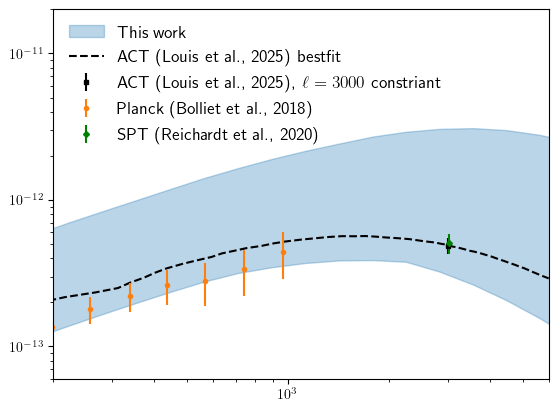

In [30]:
# Cl_yy
# fach = fac = ((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
pl.figure()
pl.fill_between(base_test.ell_array, Dlyymin, Dlyymax, color='tab:blue', alpha=0.3, label='This work')


# for Cl_yy in Cl_yy_all_samp:
#     pl.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, lw=0.5)

# vljv,vljvp, vljvn = 5.29*fac,(5.29+0.66)*fac,(5.29-0.66)*fac
# pl.errorbar(np.array([2928.3]),np.array([vljv]),yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='blue',label='ACT (Choi et al., 2020)')


vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
pl.errorbar(np.array([3000.]),np.array([vljv]),yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$ constriant')

pl.plot(ell_act_Dl_ratio, Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')


pl.errorbar(ell, Dl_yy_planck, yerr=err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')


# pl.plot(2928.3, vljv, ls='', marker='s', ms='8', color='blue', label='ACT (Choi et al., 2020)')

vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
pl.errorbar([3024],[vljv],yerr=np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label='SPT (Reichardt et al., 2020)')

pl.xscale('log')
pl.yscale('log')
pl.ylim(6e-14, 2e-11)
pl.xlim(2e2, 6e3)
pl.legend(frameon=False, fontsize=12.5, loc='upper left')




In [88]:
# np.array([[vljv-vljvn,vljvp - vljv]]).T[...,0].shape
vljv

Array([1.16913068e+02, 1.82195007e+02, 2.84857311e+02, 4.46555690e+02,
       7.01558321e+02, 1.10410887e+03, 1.74009245e+03, 2.74552048e+03,
       4.33582133e+03, 6.85225582e+03, 1.08354717e+04, 1.71420681e+04,
       2.71293239e+04, 4.29479537e+04, 6.80060719e+04, 1.07704499e+05,
       1.70602106e+05, 2.70262715e+05, 4.28182184e+05, 6.78427450e+05,
       1.07498883e+06, 1.70343251e+06, 2.69936836e+06, 4.27771927e+06,
       6.77910968e+06, 1.07433862e+07, 1.70261394e+07, 2.69833785e+07,
       4.27642194e+07, 6.77747645e+07, 1.07413301e+08, 1.70235510e+08,
       2.69801199e+08, 4.27601171e+08, 6.77696001e+08, 1.07406799e+09,
       1.70227325e+09], dtype=float64)